In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from sklearn.model_selection import train_test_split

In [7]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [8]:
fake = pd.read_csv("/content/drive/MyDrive/fake-news-detection/data/fake.csv")
true = pd.read_csv("/content/drive/MyDrive/fake-news-detection/data/true.csv")

In [9]:
# Adding the labels to both files

Fake -> 0 <br>
True -> 1





In [10]:
fake["label"] = 0
true['label'] = 1

In [11]:
# combine the Dataset
data = pd.concat([fake, true], axis=0)
data = data.reset_index(drop=True)

In [12]:
data.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [13]:
data.sample(10)

,title,text,subject,date,label
29625,Israel's Netanyahu to speak with Trump on Sunday,JERUSALEM (Reuters) - Israeli Prime Minister B...,politicsNews,"January 22, 2017",1
20475,5-STAR MOOCH Tells Graduates: “Every Single Da...,Poor 5-star Mooch. At least we know now why sh...,left-news,"Jun 4, 2016",0
41379,No angst over Turkey's air defense deal with R...,"CRAIOVA, Romania (Reuters) - NATO ally Turkey ...",worldnews,"October 10, 2017",1
14828,Democrat Mayor Proclaims He’s Barring Trump Fr...,"We can all breathe a sigh of relief, knowing t...",politics,"Dec 8, 2015",0
2916,Trump Delivers First Embarrassing Spelling Er...,"Well, no one will ever call Donald Trump the ...",News,"January 21, 2017",0
33112,Michelle Obama helps Prince Harry launch secon...,"ORLANDO, Florida (Reuters) - Britain’s Prince ...",politicsNews,"May 9, 2016",1
13389,HAS BILL CLINTON LOST IT? Watch Him Yank Ballo...,"By now, pretty much everyone has seen pictures...",politics,"Jul 29, 2016",0
25906,Factbox: Priebus the latest official to leave ...,"WASHINGTON (Reuters) - Reince Priebus, who was...",politicsNews,"July 29, 2017",1
2553,Even Donald Trump’s Inauguration Poster Has A...,I can only imagine that the stack of resumes o...,News,"February 12, 2017",0
17212,(VIDEO) WATCH WHAT HAPPENS WHEN A FOX REPORTER...,Jesse Watters confronts the board of superviso...,Government News,"Jul 8, 2015",0


In [14]:
data.shape

(44898, 5)

In [15]:
data.columns

Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

In [16]:
data.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


In [17]:
data["label"].value_counts()

,count
label,
0,23481
1,21417


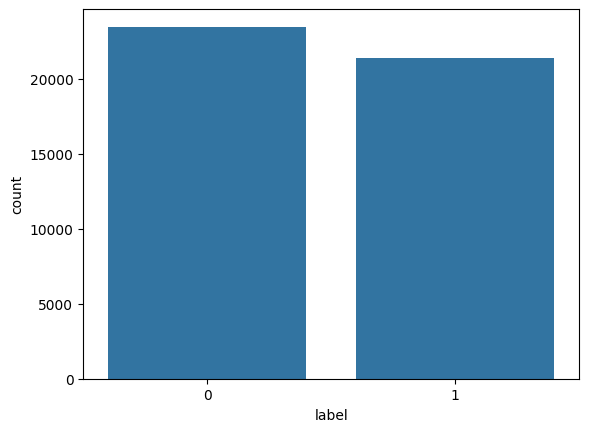

In [18]:
sns.countplot(x="label", data=data)
plt.show()

In [19]:
# extracting the required columns
# so here need only text and label column

In [20]:
data = data[['text', 'label']]

In [21]:
data.head()

,text,label
0,Donald Trump just couldn t wish all Americans ...,0
1,House Intelligence Committee Chairman Devin Nu...,0
2,"On Friday, it was revealed that former Milwauk...",0
3,"On Christmas day, Donald Trump announced that ...",0
4,Pope Francis used his annual Christmas Day mes...,0


# shuffle Dataset

In [22]:
data = data.sample(frac =1)

In [23]:
data


,text,label
28942,WASHINGTON (Reuters) - President Donald Trump’...,1
34812,ISTANBUL (Reuters) - Turkish police have detai...,1
21730,MSNBC the cable news station who hired tax ...,0
37792,"MAR DEL PLATA, Argentina/BUENOS AIRES (Reuters...",1
34313,"RANCHO MIRAGE, Calif. (Reuters) - Following is...",1
...,...,...
7924,Since Jeb Bush started to bring his mother Bar...,0
42471,LONDON (Reuters) - Tehran vowed on Tuesday to ...,1
25730,WASHINGTON (Reuters) - The White House said on...,1
814,Donald Trump dropped several shocking statemen...,0


**Text Preprocessing **

Raw text is messy. Neural networks cannot learn properly from raw text.


**Example raw text:**

*Breaking: Government announces NEW policy!!!*

**We convert it to:**

*breaking government announces new policy*

In [24]:
import re
from nltk.corpus import stopwords

# regular expression are used for removing punctuation , special characters, numbers

In [25]:
# English stops
stop_words = set(stopwords.words('english')) # set allow faster lookup

In [26]:
# function for text cleaning
def clean_text(text):

    text = text.lower()   # converting text to complete lower case

    text = re.sub(r'[^a-zA-Z]', ' ', text)  # REmove punctution and numbers like (! @ # $ % 123)

    words = text.split()  # split the words in given sentence

    words = [word for word in words if word not in stop_words]  # Removing the stopwords

    text = " ".join(words) # convert it back to sentence form

    return text

In [27]:
data['text'] = data['text'].apply(clean_text)

In [28]:
data.head()

,text,label
28942,washington reuters president donald trump nati...,1
34812,istanbul reuters turkish police detained staff...,1
21730,msnbc cable news station hired tax cheat fbi s...,0
37792,mar del plata argentina buenos aires reuters s...,1
34313,rancho mirage calif reuters following full tex...,1


C**onvert Text to Numbers**



In [29]:
from tensorflow.keras.preprocessing.text import Tokenizer
# Tokenizer create the word dictionary

In [30]:
tokenizer = Tokenizer(num_words=5000)

In [31]:
#This scans the dataset and builds vocabulary.

In [32]:
tokenizer.fit_on_texts(data["text"])

In [33]:
X = tokenizer.texts_to_sequences(data["text"])
# convert text to sequence

"government election fraud"
↓
[21, 44, 89]

"government election fraud"<br>
↓ <br>
[21,           44,      89]

In [34]:
#pad sequences

from tensorflow.keras.preprocessing.sequence import pad_sequences

X = pad_sequences(X, maxlen=500)

In [35]:
y = data["label"]

In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

In [37]:
import tensorflow as tf  # Deep Learning framework
from tensorflow.keras.models import Sequential  # Allows stacking layers one after another
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# Embedding to converts word indexes into dense vectors
# LSTM Learns patterns from sequences
# DEnse to final classification layers


Building model

In [38]:
model = Sequential()

model.add(Embedding(input_dim=5000, output_dim=128, input_length=500))

model.add(LSTM(64))  # 64 = number of neurons

model.add(Dense(1, activation='sigmoid'))   # -> to binay classification of Fake and real


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [39]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [41]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 396s 704ms/step - accuracy: 0.9974 - loss: 0.0093 - val_accuracy: 0.9942 - val_loss: 0.0226
Epoch 2/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 356s 634ms/step - accuracy: 0.9973 - loss: 0.0099 - val_accuracy: 0.9969 - val_loss: 0.0119
Epoch 3/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 399s 665ms/step - accuracy: 0.9996 - loss: 0.0025 - val_accuracy: 0.9925 - val_loss: 0.0269
Epoch 4/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 362s 629ms/step - accuracy: 0.9987 - loss: 0.0052 - val_accuracy: 0.9976 - val_loss: 0.0108
Epoch 5/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 355s 631ms/step - accuracy: 0.9995 - loss: 0.0021 - val_accuracy: 0.9954 - val_loss: 0.0164


In [42]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)

281/281 ━━━━━━━━━━━━━━━━━━━━ 28s 99ms/step - accuracy: 0.9958 - loss: 0.0134
Accuracy: 0.9954342842102051


In [44]:
predictions = model.predict(X_test)

predictions = (predictions > 0.5)

281/281 ━━━━━━━━━━━━━━━━━━━━ 23s 81ms/step


Confusion matrix

In [45]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

print(cm)

[[4692    9]
 [  32 4247]]


**4705** → TN
Fake news correctly detected as Fake

**26**  → FP
Fake news wrongly predicted as Real

**17**   → FN
Real news wrongly predicted as Fake

**4232** → TP
Real news correctly predicted as Real

In [46]:
model.save("/content/drive/MyDrive/fake-news-detection/model/fake_news_model.h5")

In [47]:
import pickle

with open("/content/drive/MyDrive/fake-news-detection/model/tokenizer.pkl","wb") as f:
    pickle.dump(tokenizer,f)

In [48]:
from tensorflow.keras.models import load_model

model = load_model(("/content/drive/MyDrive/fake-news-detection/model/fake_news_model.h5"))

In [49]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [51]:
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

In [50]:
def predict_news(news_text):

    news_text = clean_text(news_text)

    seq = tokenizer.texts_to_sequences([news_text])

    padded = pad_sequences(seq, maxlen=500)

    prediction = model.predict(padded)

    if prediction > 0.5:
        return "Real News"
    else:
        return "Fake News"

In [52]:
news ="NEW YORK (Reuters) - Passage of a long-anticipated U.S. tax overhaul has up-ended the bond market’s favorite trade of the year as yields on some long-dated Treasuries shot to their highest in months, but doubts that the tax cuts will fuel inflation have many investors confident the reversal will be short-lived. The view that the U.S. Federal Reserve will keep raising short-term interest rates, even as inflation remains subdued, has made longer-dated Treasury bonds more appealing to own than short-dated ones. This has made so-called yield curve flattener trades - a bet that the gap between short- and long-dated bond yields will narrow - a profitable bet in the bond market this year. Investors’ appetite for this trade drove the yield curve to its flattest level in a decade earlier this week. However, a sharp reversal got underway as the tax bill’s passage became certain, paving the way for a bigger government deficit and more federal borrowing. “It’s a great time to cash out,” said Brian Reynolds, asset class strategist at New York-based Canaccord Genuity.  Both Republican-controlled Congressional chambers have approved the tax legislation, and President Donald Trump is expected to sign it in the days ahead.    The Treasury market selloff pushed the benchmark 10-year yield up to nearly 2.50 percent, its highest in nine months and the 30-year yield to around 2.87 percent, a five-week peak. Some analysts reckoned the jump in yields reflects investors demanding higher compensation, or term premium, in case the tax cuts stoke inflation and hurt longer-dated bonds. How long this prevails is an open question, though, given previous episodes of curve steepening in the last year have quickly faded. “In other words, sharp term premium moves tend not be permanent,” Cornerstone Macro analysts said in a note on Wednesday. In late afternoon trading, the spread between two-year and 10-year Treasury yields was 63 basis points versus 60 basis points on Tuesday and around 51 earlier in the week. Even with this week’s steepening, the two-to-10-year part of the curve has flattened nearly 63 basis points this year. Curve flatteners are seen as likely to regain popularity in the long run due to a low inflation outlook and sturdy global demand for long-dated U.S. debt. In the short term, however, it may prove a choppy trade as investors gauge the bill’s impact. “It’s hard to predict how the yield curve would behave in the short term. The biggest question is the timing and level of cash flows going to the government after tax reform,” Canaccord’s Reynolds said. One factor is the mountain of corporate cash held overseas. As part of the new tax code, U.S. multinational companies could bring back some of the estimated $2.6 trillion in business profits they have overseas and the Treasury Department could benefit from the taxes on the repatriated money.  Reynolds estimated the Treasury might receive as much as $225 billion in tax receipts in 2018 if the companies bring back all their overseas profits. This means the government could issue fewer two- and three-year Treasury securities, pressuring these yields lower and steepening the yield curve into 2019, he said.  Independent government estimates suggest the tax plan could add at least $1 trillion to the $20 trillion in national debt in 10 years as the Treasury Department would ratchet up borrowing to compensate for shortfalls in tax receipts. The degree to which the bill may spur both business investment and consumer spending, which could lift tax receipts and cap the rise in the deficit, is another key unknown for the shape of the yield curve going forward. Still, the dominant view on Wall Street remains that the cut will provide only a short-term bump up in economic growth, and many analysts expect the longer-term curve-flattening trend to reassert itself in the year ahead. “Accordingly, we maintain our conviction on curve flattening going into 2018,” Morgan Stanley analysts wrote in a note on Wednesday.  "
result = predict_news(news)

print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step
Real News


In [ ]:
# writeing the streamlit application
%%writefile /content/drive/MyDrive/fake-news-detection/model/app.py
import streamlit as st
import pickle
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

model = load_model("/content/drive/MyDrive/fake-news-detection/model/fake_news_model.h5")

with open("tokenizer.pkl","rb") as f:
    tokenizer = pickle.load(f)

st.title("Fake News Detection System")

news_text = st.text_area("Enter News Article")

if st.button("Predict"):

    news_text = clean_text(news_text)

    seq = tokenizer.texts_to_sequences([news_text])

    padded = pad_sequences(seq, maxlen=500)

    prediction = model.predict(padded)

    if prediction > 0.5:
        st.success("This is Real News")
    else:
        st.error("This is Fake News")

Overwriting /content/drive/MyDrive/fake-news-detection/model/app.py


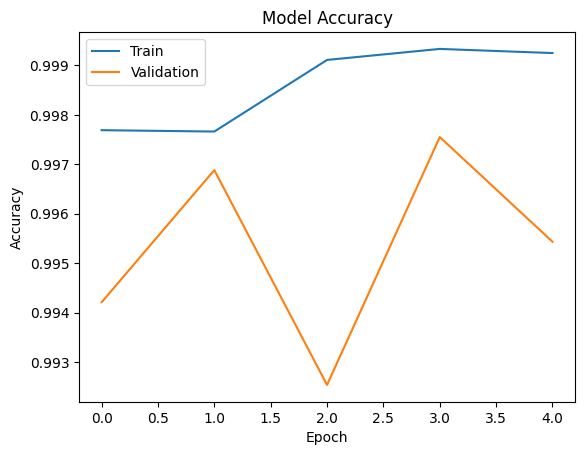

In [53]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])

plt.show()

In [54]:
import gradio as gr
import pickle
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [55]:
import pickle
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/fake-news-detection/model/fake_news_model.h5")

with open("/content/drive/MyDrive/fake-news-detection/model/tokenizer.pkl","rb") as f:
    tokenizer = pickle.load(f)

In [56]:
def predict_news(news):

    news = clean_text(news)

    seq = tokenizer.texts_to_sequences([news])

    padded = pad_sequences(seq, maxlen=500)

    prediction = model.predict(padded)[0][0]

    if prediction > 0.5:
        return "Real News"
    else:
        return "Fake News"

In [57]:
interface = gr.Interface(
    fn=predict_news,
    inputs="textbox",
    outputs="text",
    title="Fake News Detection",
    description="Enter a news article and the model will predict if it is Fake or Real."
)

In [58]:
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://98426d7f603dffe043.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
